In [1]:
print("HELO")

HELO


In [10]:
import torch
from transformers import AutoImageProcessor, AutoModel
from PIL import Image

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

processor = AutoImageProcessor.from_pretrained("facebook/dinov2-base")
model = AutoModel.from_pretrained("facebook/dinov2-base").to(device)

def extract_embedding(image_path):

    img = Image.open(image_path).convert("RGB")
    inputs = processor(images=img, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        embedding = outputs.last_hidden_state.mean(dim=1)

    return embedding.cpu().numpy().squeeze()

Loading weights: 100%|██████████| 223/223 [00:00<00:00, 6128.57it/s]


In [19]:
import numpy as np

def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

embedding_1 = extract_embedding("query_2.png")
embedding_2 = extract_embedding("sample_chrome.png")

similarity = cosine_similarity(embedding_1, embedding_2)
print(f"Cosine similarity: {similarity:.4f}")

Cosine similarity: 0.9292


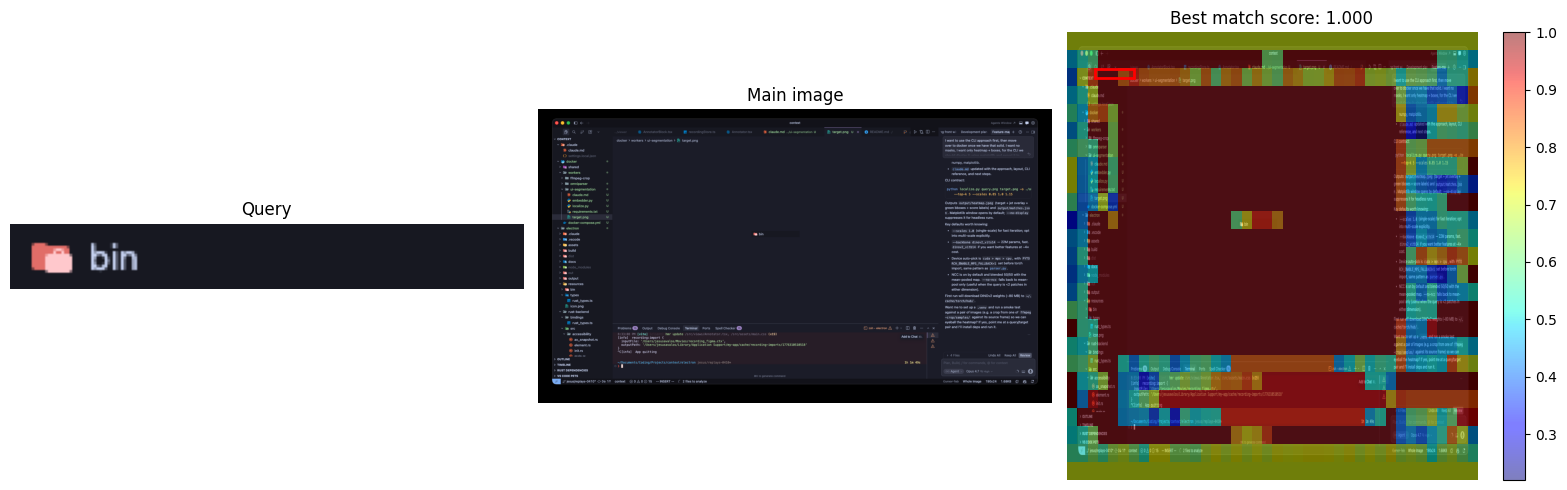

In [12]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

def embed_image(model, processor, image, device):
    inputs = processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state.mean(dim=1)  # (1, dim)

def sliding_window_similarity(model, processor, query_image, main_image, device, stride=None):
    qw, qh = query_image.size
    mw, mh = main_image.size
    stride = stride or max(qw // 4, qh // 4, 10)

    query_emb = embed_image(model, processor, query_image, device)
    query_emb = query_emb / query_emb.norm(dim=-1, keepdim=True)

    xs = range(0, mw - qw + 1, stride)
    ys = range(0, mh - qh + 1, stride)

    sim_map = np.zeros((len(list(ys)), len(list(xs))))

    for j, y in enumerate(ys):
        for i, x in enumerate(xs):
            patch = main_image.crop((x, y, x + qw, y + qh))
            patch_emb = embed_image(model, processor, patch, device)
            patch_emb = patch_emb / patch_emb.norm(dim=-1, keepdim=True)
            sim_map[j, i] = float(query_emb @ patch_emb.T)

    return sim_map, list(xs), list(ys)

# --- Run ---
query_image = Image.open("query_1.png").convert("RGB")
main_image  = Image.open("sample.png").convert("RGB")

sim_map, xs, ys = sliding_window_similarity(model, processor, query_image, main_image, device)

# Best match
best_j, best_i = np.unravel_index(sim_map.argmax(), sim_map.shape)
best_x, best_y = xs[best_i], ys[best_j]
qw, qh = query_image.size

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(query_image)
axes[0].set_title("Query")
axes[0].axis("off")

axes[1].imshow(main_image)
axes[1].set_title("Main image")
axes[1].axis("off")

axes[2].imshow(main_image)
heatmap = axes[2].imshow(
    sim_map, cmap="jet", alpha=0.5,
    extent=[xs[0], xs[-1] + qw, ys[-1] + qh, ys[0]],
    aspect="auto"
)
plt.colorbar(heatmap, ax=axes[2])
rect = patches.Rectangle((best_x, best_y), qw, qh,
                           linewidth=2, edgecolor="red", facecolor="none")
axes[2].add_patch(rect)
axes[2].set_title(f"Best match score: {sim_map.max():.3f}")
axes[2].axis("off")

plt.tight_layout()
plt.show()


In [26]:
import cv2

def propose_ui_boxes(img, min_area=500, max_area_ratio=0.3, pad=4):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    h, w = gray.shape
    total_area = h * w

    edges = cv2.Canny(gray, threshold1=50, threshold2=150)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (7, 7))
    closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=1)

    contours, _ = cv2.findContours(closed, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

    boxes = []
    seen = set()

    for c in contours:
        x, y, bw, bh = cv2.boundingRect(c)
        area = bw * bh

        if area < min_area:
            continue
        if area > total_area * max_area_ratio:
            continue

        key = (x, y, bw, bh)
        if key in seen:
            continue
        seen.add(key)

        x1 = max(0, x - pad)
        y1 = max(0, y - pad)
        x2 = min(w, x + bw + pad)
        y2 = min(h, y + bh + pad)
        boxes.append((x1, y1, x2, y2))

    return boxes


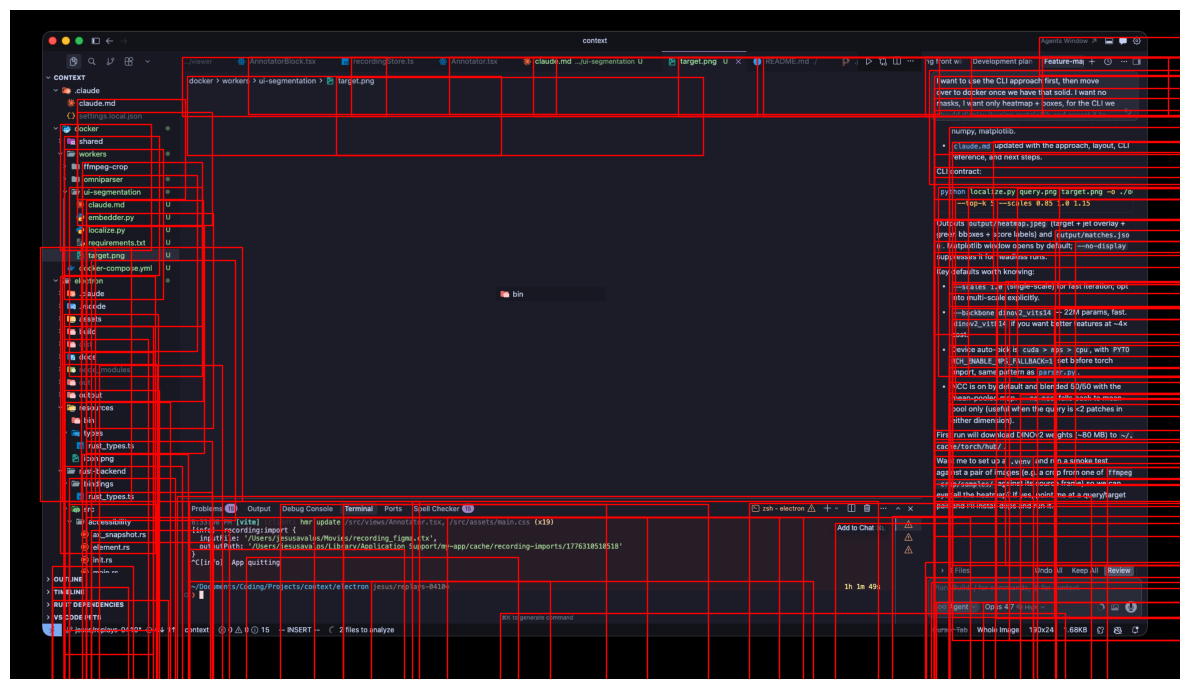

In [27]:
main_image = cv2.imread("sample.png")
main_image = cv2.cvtColor(main_image, cv2.COLOR_BGR2RGB)
boxes = propose_ui_boxes(main_image)
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.imshow(main_image)
for box in boxes:
    x, y, w, h = box
    rect = patches.Rectangle((x, y), w, h, linewidth=1, edgecolor="red", facecolor="none")
    ax.add_patch(rect)
ax.axis("off")
plt.tight_layout()
plt.show()

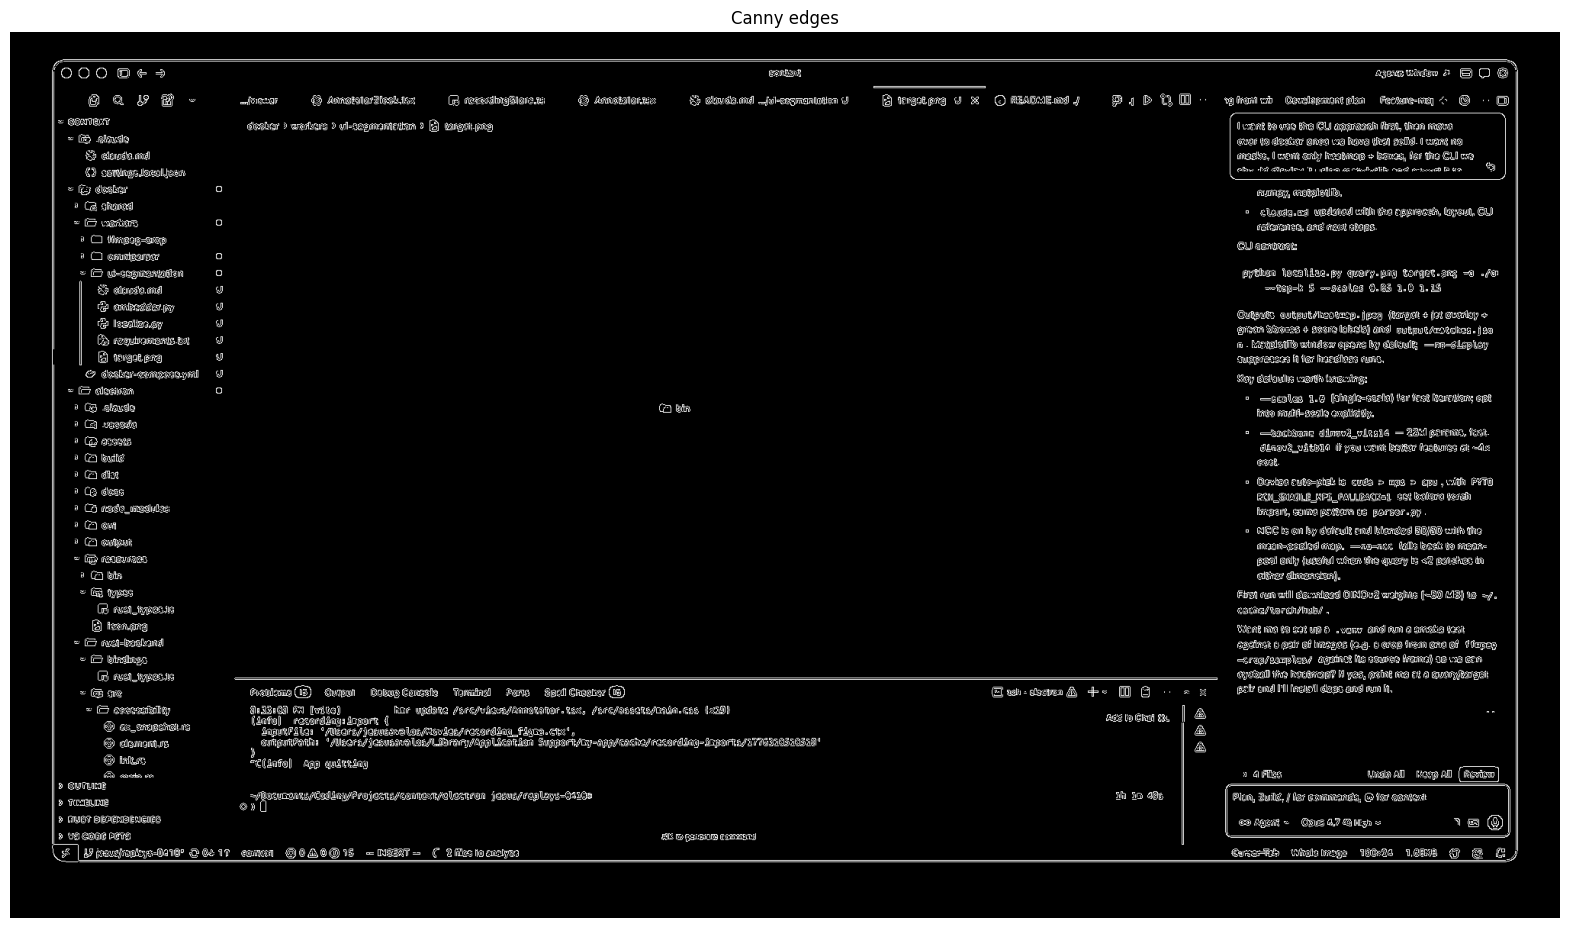

In [38]:
main_image = cv2.imread("sample.png")
gray = cv2.cvtColor(main_image, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, threshold1=100, threshold2=150)

plt.figure(figsize=(20, 13))
plt.imshow(edges, cmap="gray")
plt.axis("off")
plt.title("Canny edges")
plt.show()


In [ ]:
import easyocr
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

ocr_reader = easyocr.Reader(["en"], gpu=(device.type == "cuda"))


def ocr_image(image_path, target_min_dim=400):
    """Return list of (bbox, text, conf). Upscales tiny images so EasyOCR's
    detector has enough resolution to find text."""
    img = cv2.imread(image_path)
    h, w = img.shape[:2]
    min_dim = min(h, w)
    scale = 1.0

    if min_dim < target_min_dim:
        scale = target_min_dim / min_dim
        img = cv2.resize(img, None, fx=scale, fy=scale,
                         interpolation=cv2.INTER_CUBIC)

    results = ocr_reader.readtext(img)
    # Rescale bboxes back to original pixel space.
    rescaled = []
    for bbox, text, conf in results:
        if not text.strip():
            continue
        bbox = [[x / scale, y / scale] for (x, y) in bbox]
        rescaled.append((bbox, text.strip(), conf))
    return rescaled


def draw_ocr(image, results, title=""):
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    ax.imshow(image)
    for bbox, text, conf in results:
        xs = [p[0] for p in bbox]
        ys = [p[1] for p in bbox]
        x1, y1, x2, y2 = min(xs), min(ys), max(xs), max(ys)
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=1.5, edgecolor="cyan", facecolor="none",
        )
        ax.add_patch(rect)
        ax.text(
            x1, max(y1 - 4, 0), f"{text} ({conf:.2f})",
            color="black", fontsize=8,
            bbox=dict(facecolor="cyan", alpha=0.8, pad=1),
        )
    ax.set_title(title)
    ax.axis("off")
    plt.tight_layout()
    plt.show()


# --- Run ---
query_path = "query_1.png"
target_path = "sample.png"

query_image = Image.open(query_path).convert("RGB")
main_image = Image.open(target_path).convert("RGB")

query_results = ocr_image(query_path)
target_results = ocr_image(target_path)

print("Query OCR:", [t for (_, t, _) in query_results])
print(f"Target OCR: {len(target_results)} text regions")

draw_ocr(query_image, query_results, title="Query OCR")
draw_ocr(main_image, target_results, title="Target OCR")


Loading weights: 100%|██████████| 473/473 [00:00<00:00, 57437.92it/s]


BLIP description: a black background with a red and white logo
Prompt: "a black background with a red and white logo" — found 1 matches


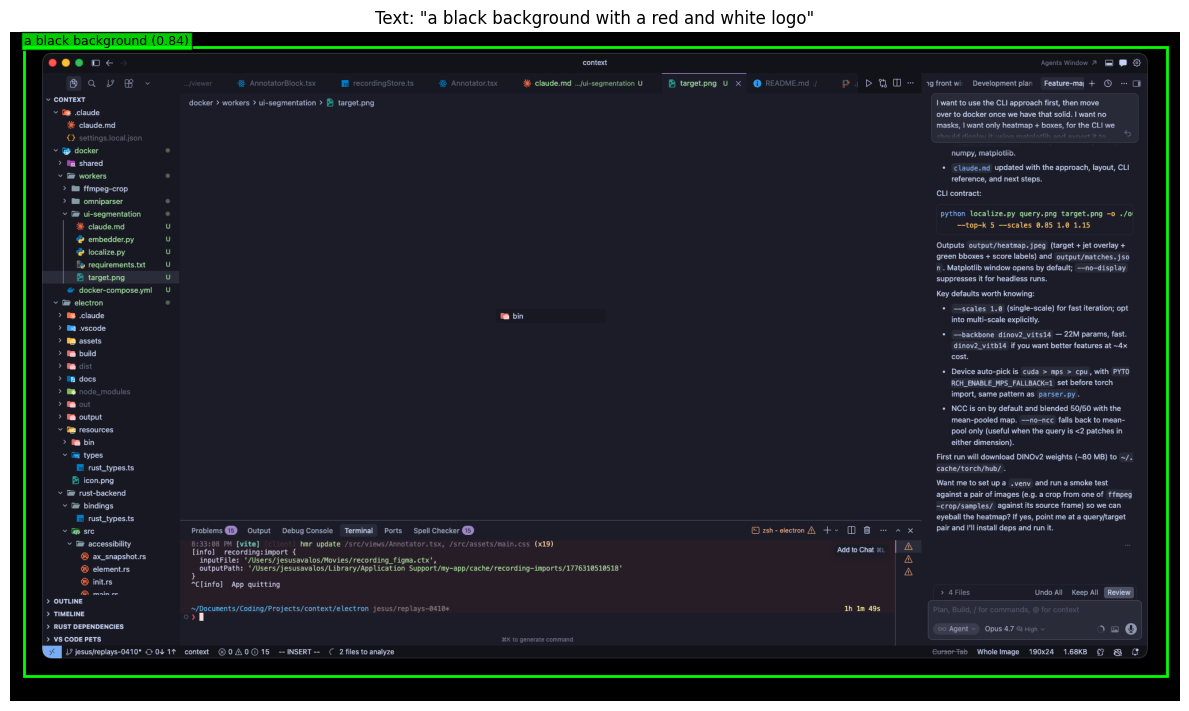

{'scores': tensor([0.8426], device='mps:0'),
 'boxes': tensor([[  24.2158,   26.3898, 2009.3453, 1118.8616]], device='mps:0'),
 'text_labels': ['a black background'],
 'labels': ['a black background']}

In [43]:
from transformers import BlipProcessor, BlipForConditionalGeneration

blip_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
blip_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
).to(device)


def describe_image(image, max_new_tokens=40):
    """Generate a free-form caption describing the image."""
    inputs = blip_processor(image, return_tensors="pt").to(device)
    with torch.no_grad():
        out = blip_model.generate(**inputs, max_new_tokens=max_new_tokens)
    return blip_processor.decode(out[0], skip_special_tokens=True)


def find_in_target(target_image, text, threshold=0.3, text_threshold=0.25):
    """Locate `text` in `target_image` using GroundingDINO and visualize."""
    results = grounding_dino_detect(
        target_image, text,
        threshold=threshold,
        text_threshold=text_threshold,
    )
    print(f'Prompt: "{text}" — found {len(results["boxes"])} matches')
    draw_detections(target_image, results, title=f'Text: "{text}"')
    return results


# --- Run ---
description = describe_image(query_image)
print("BLIP description:", description)

find_in_target(main_image, description)


Prompt: "chat box" — found 1 matches


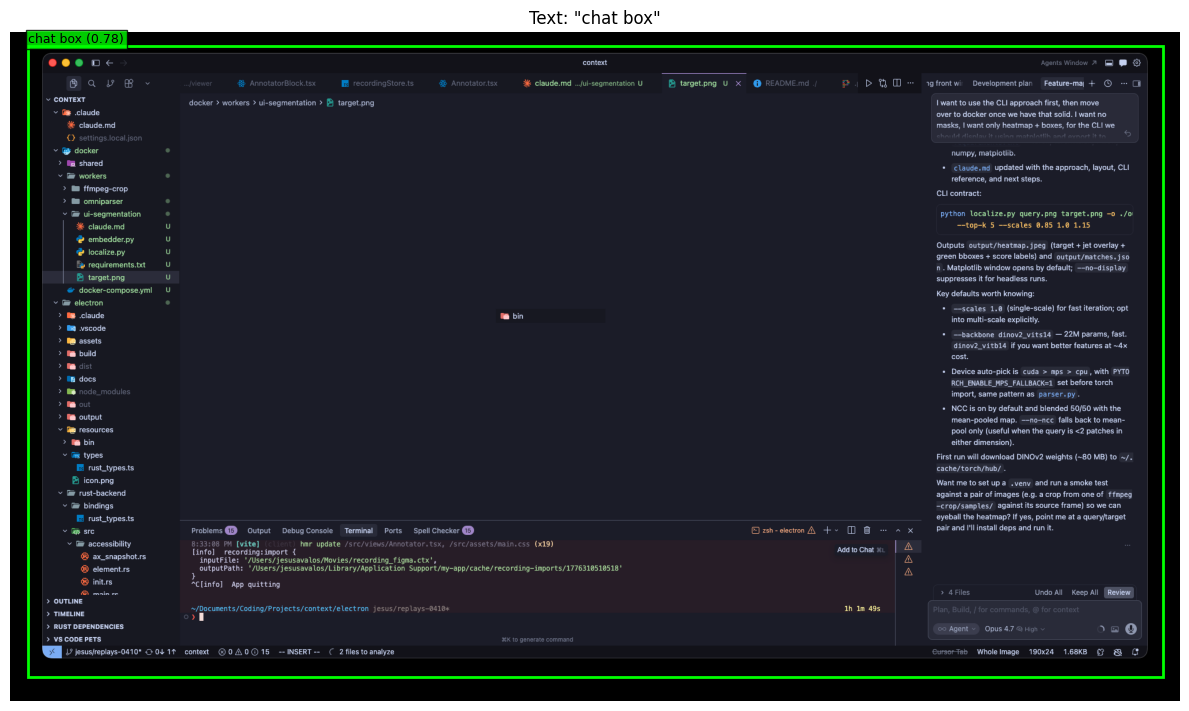

{'scores': tensor([0.7841], device='mps:0'),
 'boxes': tensor([[  31.2022,   23.3079, 2002.0720, 1120.3885]], device='mps:0'),
 'text_labels': ['chat box'],
 'labels': ['chat box']}

In [ ]:
find_in_target(main_image, "che")